# ValuingH0M3 

It is a notebook where you will find an EDA workflow about the dataset "USA Real Estate Dataset" in which we have variables such as : 
1. bath
2. bed 
3. acre_lot 
4. house_size 
5. status
6. city    
7. state 
8. prev_sold_date 

All of these features will help us predict the target variable, 'price'. We consider this relevant for a small or medium-sized real estate company in the U.S. because these features are common and relatively easy to obtain.

## Read the data and become into a dataframe using pandas 

In [2]:

import pandas as pd 

data = pd.read_csv("Real_Estate_Sales_2001-2024_GL_20260814.csv")

# Verifing with the first five samples
data.head()

/tmp/ipykernel_67324/1435552656.py:3: DtypeWarning: Columns (7,8,9,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("Real_Estate_Sales_2001-2024_GL_20260814.csv")


,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location
0,24079,2024,09/26/2025,Ashford,SECKAR RD,"$54,460.00","$95,000.00",0.5732,Vacant Land,NaN,NaN,MBL 23 D 4,NaN,NaN
1,240171,2024,06/06/2025,Berlin,251400,"$251,400.00","$350,000.00",0.7182,Commercial,NaN,25 - Other,NaN,NaN,NaN
2,24071,2024,12/31/2024,Bethel,25.5 TAYLOR AVENUE,"$221,480.00","$480,000.00",0.4614,Residential,Two Family,NaN,NaN,NaN,NaN
3,24018,2024,12/18/2024,Columbia,PINE STREET,"$3,640.00","$15,000.00",0.242667,Vacant Land,NaN,NaN,VACANT LAND,NaN,NaN
4,240008,2024,10/11/2024,Cromwell,BIRCH COURT,"$96,950.00","$179,900.00",0.5389,Residential,Condo,NaN,NaN,NaN,NaN


## Normalize fields and remove duplicated rows before partitioning

### Remove duplicated rows and keeping the first apariance

In [3]:
print("This is the length of the dataframe before removing duplicates:", len(data))
data = data.drop_duplicates(keep='first')
print("This is the length of the dataset after removing duplicated rows:", len(data))


This is the length of the dataframe before removing duplicates: 1188997
This is the length of the dataset after removing duplicated rows: 1188997


### Remove unnecesaary features that goes beyond the project scope

In the case of address it is because it has a high cardinality, so almost each house as a diferente one. 

In [4]:

columns_delete = ['Location','Assessor Remarks','OPM remarks', 'Address', 'Non Use Code']

data = data.drop(columns=columns_delete)

data.head()

,Serial Number,List Year,Date Recorded,Town,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
0,24079,2024,09/26/2025,Ashford,"$54,460.00","$95,000.00",0.5732,Vacant Land,NaN
1,240171,2024,06/06/2025,Berlin,"$251,400.00","$350,000.00",0.7182,Commercial,NaN
2,24071,2024,12/31/2024,Bethel,"$221,480.00","$480,000.00",0.4614,Residential,Two Family
3,24018,2024,12/18/2024,Columbia,"$3,640.00","$15,000.00",0.242667,Vacant Land,NaN
4,240008,2024,10/11/2024,Cromwell,"$96,950.00","$179,900.00",0.5389,Residential,Condo


### Becoming all monetary features into numbers 

In [5]:
columns = ['Assessed Value','Sale Amount']
for column in columns: 
    data[column] =  data[column].astype(str).str.replace('$', '').str.replace(',', '').astype(float)

data.head()



,Serial Number,List Year,Date Recorded,Town,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
0,24079,2024,09/26/2025,Ashford,54460.0,95000.0,0.5732,Vacant Land,NaN
1,240171,2024,06/06/2025,Berlin,251400.0,350000.0,0.7182,Commercial,NaN
2,24071,2024,12/31/2024,Bethel,221480.0,480000.0,0.4614,Residential,Two Family
3,24018,2024,12/18/2024,Columbia,3640.0,15000.0,0.242667,Vacant Land,NaN
4,240008,2024,10/11/2024,Cromwell,96950.0,179900.0,0.5389,Residential,Condo


### Creating new "features" from old

This process converts Date Recorded into three features: 'Day Recorded', 'Month Recorded', and 'Year Recorded'. This lets us treat the date as numeric information and examine relationships among its components during EDA. 

In [6]:
data['Date Recorded'] = pd.to_datetime(
    data['Date Recorded'],
    errors='coerce'
)

data['Year Recorded'] = data['Date Recorded'].dt.year
data['Month Recorded'] = data['Date Recorded'].dt.month
data['Day Recorded'] = data['Date Recorded'].dt.day

In [7]:

data = data.drop('Date Recorded', axis=1)
data.head()

,Serial Number,List Year,Town,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Year Recorded,Month Recorded,Day Recorded
0,24079,2024,Ashford,54460.0,95000.0,0.5732,Vacant Land,NaN,2025.0,9.0,26.0
1,240171,2024,Berlin,251400.0,350000.0,0.7182,Commercial,NaN,2025.0,6.0,6.0
2,24071,2024,Bethel,221480.0,480000.0,0.4614,Residential,Two Family,2024.0,12.0,31.0
3,24018,2024,Columbia,3640.0,15000.0,0.242667,Vacant Land,NaN,2024.0,12.0,18.0
4,240008,2024,Cromwell,96950.0,179900.0,0.5389,Residential,Condo,2024.0,10.0,11.0


### Delete samples that do not have the target variable Sale Amount

In [8]:
data = data.dropna(subset=['Sale Amount'])
print("This is now the new length of the dataset: ",len(data))

This is now the new length of the dataset:  1188997


## Partitioning the dataset 

In [9]:
!pip install scikit-learn


In [10]:
from sklearn.model_selection import train_test_split

y = data['Sale Amount']
X = data.drop(columns=['Sale Amount','Sales Ratio'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=77)

## Minimal Imputing without EDA

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline



categorical_columns= ['Town','Property Type','Residential Type']
numerical_columns = [column for column in X.columns if column not in categorical_columns]


minimal_preprocessing = ColumnTransformer(
    transformers=[
        (
            'categorical',
            Pipeline(steps=[
                (
                    'imputer',
                    SimpleImputer(
                        strategy='constant',
                        fill_value='Missing'
                    )
                ),
                (
                    'onehot',
                    OneHotEncoder(
                        handle_unknown='ignore'
                    )
                )
            ]),
            categorical_columns
        ),
        (
            'numerical',
            SimpleImputer(strategy='median'),
            numerical_columns
        )
    ]
)

X_train_minimal = minimal_preprocessing.fit_transform(X_train)
X_test_minimal = minimal_preprocessing.transform(X_test)

# Get and print what we got after minimal imputer

print(X_train_minimal.shape)
print(X_test_minimal.shape)
result_columns = (minimal_preprocessing.get_feature_names_out())
print(result_columns)

(951197, 194)
(237800, 194)
['categorical__Town_***Unknown***' 'categorical__Town_Andover'
 'categorical__Town_Ansonia' 'categorical__Town_Ashford'
 'categorical__Town_Avon' 'categorical__Town_Barkhamsted'
 'categorical__Town_Beacon Falls' 'categorical__Town_Berlin'
 'categorical__Town_Bethany' 'categorical__Town_Bethel'
 'categorical__Town_Bethlehem' 'categorical__Town_Bloomfield'
 'categorical__Town_Bolton' 'categorical__Town_Bozrah'
 'categorical__Town_Branford' 'categorical__Town_Bridgeport'
 'categorical__Town_Bridgewater' 'categorical__Town_Bristol'
 'categorical__Town_Brookfield' 'categorical__Town_Brooklyn'
 'categorical__Town_Burlington' 'categorical__Town_Canaan'
 'categorical__Town_Canterbury' 'categorical__Town_Canton'
 'categorical__Town_Chaplin' 'categorical__Town_Cheshire'
 'categorical__Town_Chester' 'categorical__Town_Clinton'
 'categorical__Town_Colchester' 'categorical__Town_Colebrook'
 'categorical__Town_Columbia' 'categorical__Town_Cornwall'
 'categorical__Town_Cov

### Verifing that the minimal imputing process worked 

In [12]:
# check if rows concur 
assert X_train_minimal.shape[0] == y_train.shape[0]
assert X_test_minimal.shape[0] == y_test.shape[0]

## check NaNs 
import numpy as np
from scipy import sparse

if sparse.issparse(X_train_minimal):
    print(np.isnan(X_train_minimal.data).sum())
    print(np.isnan(X_test_minimal.data).sum())

0
0


## Modeling with the minimum cleaned dataset

In [13]:
from sklearn.linear_model import LinearRegression

modelo_minimal = LinearRegression()
modelo_minimal.fit(X_train_minimal,y_train)
y_test_minimal_pred= modelo_minimal.predict(X_test_minimal)



## Graph with predicted vs real amount sold

In [14]:
!pip install matplotlib

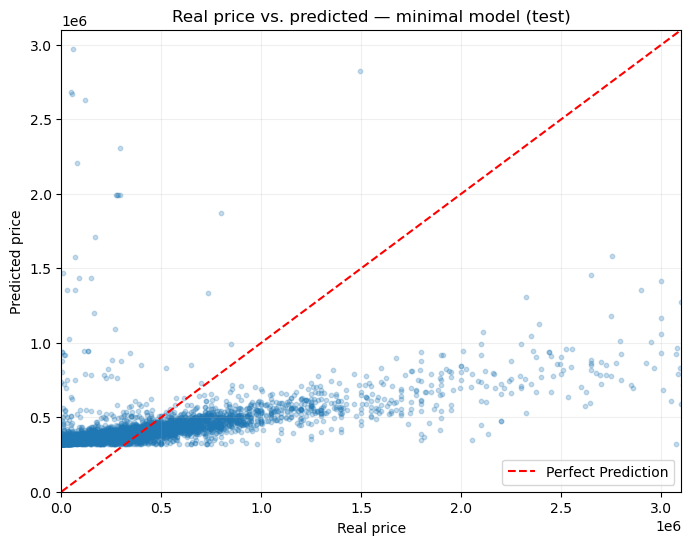

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Real and predicted values from the same test set
y_test_graph = y_test.to_numpy()


rng = np.random.default_rng(42)

indexs = rng.choice(len(y_test_graph),size=min(10_000, len(y_test_graph)),replace=False)

y_test_graph_muestra = y_test_graph[indexs]
y_test_minimal_pred_muestra = (y_test_minimal_pred[indexs])


minimal_limit = min(0,np.quantile(y_test_graph, 0.01),np.quantile(y_test_minimal_pred, 0.01))
maximal_limit = max(np.quantile(y_test_graph, 0.99),np.quantile(y_test_minimal_pred, 0.99))

plt.figure(figsize=(8, 6))
plt.scatter(y_test_graph_muestra,y_test_minimal_pred_muestra,alpha=0.25,s=10)
plt.plot([minimal_limit, maximal_limit],[minimal_limit, maximal_limit],'--',color='red',label='Perfect Prediction')

plt.xlim(minimal_limit, maximal_limit)
plt.ylim(minimal_limit, maximal_limit)

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title('Real price vs. predicted — minimal model (test)'
)

plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Some metrics 


In [16]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)


mae_minimal = mean_absolute_error(y_test,y_test_minimal_pred)
rmse_minimal = mean_squared_error(y_test,y_test_minimal_pred) ** 0.5
r2_minimal = r2_score(y_test,y_test_minimal_pred)

print("MAE:", mae_minimal)
print("RMSE:", rmse_minimal)
print("R²:", r2_minimal)

MAE: 280454.6368292131
RMSE: 1728183.545935925
R²: 0.17480298311919906


## Now lets try with Ridge

In [17]:
from sklearn.linear_model import Ridge

modelo_minimal = Ridge(
    alpha=1.0,
    solver='lsqr'
)

modelo_minimal.fit(X_train_minimal, y_train)

y_test_minimal_pred = modelo_minimal.predict(X_test_minimal)

### Graph with Ridge 

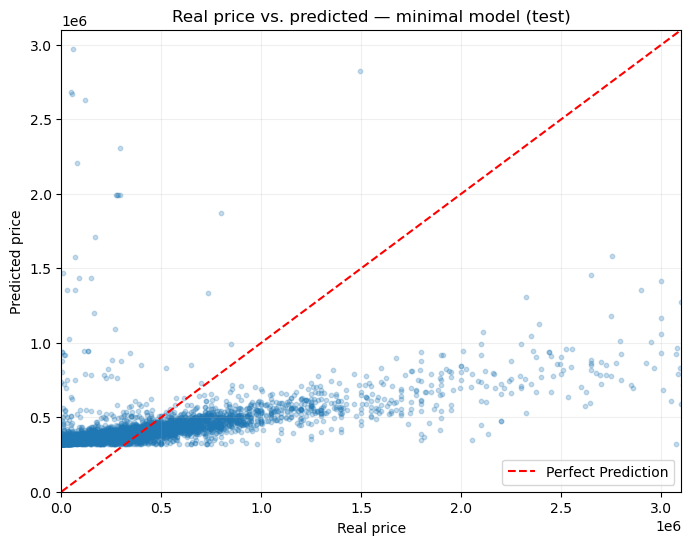

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Real and predicted values from the same test set
y_test_graph = y_test.to_numpy()


rng = np.random.default_rng(42)

indexs = rng.choice(len(y_test_graph),size=min(10_000, len(y_test_graph)),replace=False)

y_test_graph_muestra = y_test_graph[indexs]
y_test_minimal_pred_muestra = (y_test_minimal_pred[indexs])


minimal_limit = min(0,np.quantile(y_test_graph, 0.01),np.quantile(y_test_minimal_pred, 0.01))
maximal_limit = max(np.quantile(y_test_graph, 0.99),np.quantile(y_test_minimal_pred, 0.99))

plt.figure(figsize=(8, 6))
plt.scatter(y_test_graph_muestra,y_test_minimal_pred_muestra,alpha=0.25,s=10)
plt.plot([minimal_limit, maximal_limit],[minimal_limit, maximal_limit],'--',color='red',label='Perfect Prediction')

plt.xlim(minimal_limit, maximal_limit)
plt.ylim(minimal_limit, maximal_limit)

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title('Real price vs. predicted — minimal model (test)'
)

plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Metrics of Ridge

In [19]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)


mae_minimal = mean_absolute_error(y_test,y_test_minimal_pred)
rmse_minimal = mean_squared_error(y_test,y_test_minimal_pred) ** 0.5
r2_minimal = r2_score(y_test,y_test_minimal_pred)

print("MAE:", mae_minimal)
print("RMSE:", rmse_minimal)
print("R²:", r2_minimal)

MAE: 280454.6368292131
RMSE: 1728183.545935925
R²: 0.17480298311919906


## Lets start with EDA

In [20]:
print("This is the general structure of the dataset, lets remember")
print("Matrix with features")
X.head()




This is the general structure of the dataset, lets remember
Matrix with features


,Serial Number,List Year,Town,Assessed Value,Property Type,Residential Type,Year Recorded,Month Recorded,Day Recorded
0,24079,2024,Ashford,54460.0,Vacant Land,NaN,2025.0,9.0,26.0
1,240171,2024,Berlin,251400.0,Commercial,NaN,2025.0,6.0,6.0
2,24071,2024,Bethel,221480.0,Residential,Two Family,2024.0,12.0,31.0
3,24018,2024,Columbia,3640.0,Vacant Land,NaN,2024.0,12.0,18.0
4,240008,2024,Cromwell,96950.0,Residential,Condo,2024.0,10.0,11.0


Measures of central tendency

Variables of time (List Year, Year Recorded, Month Recorded, Day Recorded)


Variable List Year

Mean of the variable List Year:  2012.1635084024601
Count per year : 
 List Year
2001    59584
2002    59682
2003    64239
2004    84056
2005    61602
2006    48785
2007    35617
2008    32735
2009    42508
2010    33491
2011    31065
2012    35973
2013    39943
2014    49563
2015    46651
2016    49773
2017    45691
2018    50709
2019    58954
2020    66592
2021    56946
2022    43470
2023    44093
2024    47275
Name: count, dtype: int64

Variable Year Recorded

Mean of the variable Year Recorded:  2012.9078772245975
Count per year : 
 Year Recorded
1999.0        1
2001.0    14291
2002.0    60207
2003.0    56317
2004.0    73943
2005.0    79566
2006.0    57250
2007.0    46138
2008.0    34195
2009.0    36305
2010.0    39128
2011.0    32088
2012.0    32568
2013.0    37513
2014.0    41941
2015.0    48894
2016.0    47611
2017.0    48493
2018.0    47165
2019.0    52

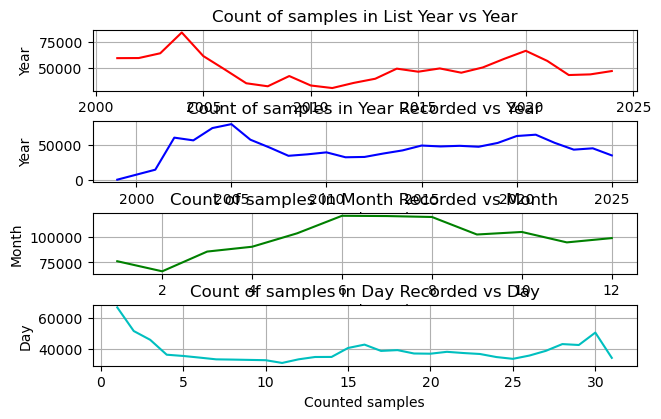

In [21]:
print("Measures of central tendency\n")
print("Variables of time (List Year, Year Recorded, Month Recorded, Day Recorded)\n")


plt.figure(1)


print("\nVariable List Year\n")
print("Mean of the variable List Year: ", X['List Year'].mean())

count_per_year_list_year = X['List Year'].value_counts().sort_index()
print("Count per year : \n", count_per_year_list_year)

plt.subplot(411)
plt.plot(count_per_year_list_year.index, count_per_year_list_year.values,'r') 
plt.title("Count of samples in List Year vs Year")
plt.ylabel("Year")
plt.xlabel("Counted samples")
plt.grid(True)

print("\nVariable Year Recorded\n")
print("Mean of the variable Year Recorded: ", X['Year Recorded'].mean())

count_per_year_year_recorded = X['Year Recorded'].value_counts().sort_index()
print("Count per year : \n", count_per_year_year_recorded)

plt.subplot(412)
plt.plot(count_per_year_year_recorded.index,count_per_year_year_recorded.values, 'b') 
plt.title("Count of samples in Year Recorded vs Year")
plt.ylabel("Year")
plt.xlabel("Counted samples")
plt.grid(True)

print("\nVariable Month Recorded\n")
print("Mean of the variable Year Recorded: ", X['Year Recorded'].mean())

count_per_year_month_recorded = X['Month Recorded'].value_counts().sort_index()
print("Count per year : \n", count_per_year_month_recorded)

plt.subplot(413)
plt.plot(count_per_year_month_recorded.index,count_per_year_month_recorded.values, 'g') 
plt.title("Count of samples in Month Recorded vs Month")
plt.ylabel("Month")
plt.xlabel("Counted samples")
plt.grid(True)


print("\nVariable Day Recorded\n")
print("Mean of the variable Day Recorded: ", X['Day Recorded'].mean())

count_per_year_day_recorded = X['Day Recorded'].value_counts().sort_index()
print("Count per year : \n", count_per_year_day_recorded)

plt.subplot(414)
plt.plot(count_per_year_day_recorded.index,count_per_year_day_recorded.values, 'c') 
plt.title("Count of samples in Day Recorded vs Day")
plt.ylabel("Day")
plt.xlabel("Counted samples")
plt.grid(True)

plt.subplots_adjust(top=0.9, bottom=0.2, left=0.10, right=0.95, hspace=0.5, wspace=1)
plt.show()


### Categorical classes

In [22]:
X.head()

,Serial Number,List Year,Town,Assessed Value,Property Type,Residential Type,Year Recorded,Month Recorded,Day Recorded
0,24079,2024,Ashford,54460.0,Vacant Land,NaN,2025.0,9.0,26.0
1,240171,2024,Berlin,251400.0,Commercial,NaN,2025.0,6.0,6.0
2,24071,2024,Bethel,221480.0,Residential,Two Family,2024.0,12.0,31.0
3,24018,2024,Columbia,3640.0,Vacant Land,NaN,2024.0,12.0,18.0
4,240008,2024,Cromwell,96950.0,Residential,Condo,2024.0,10.0,11.0


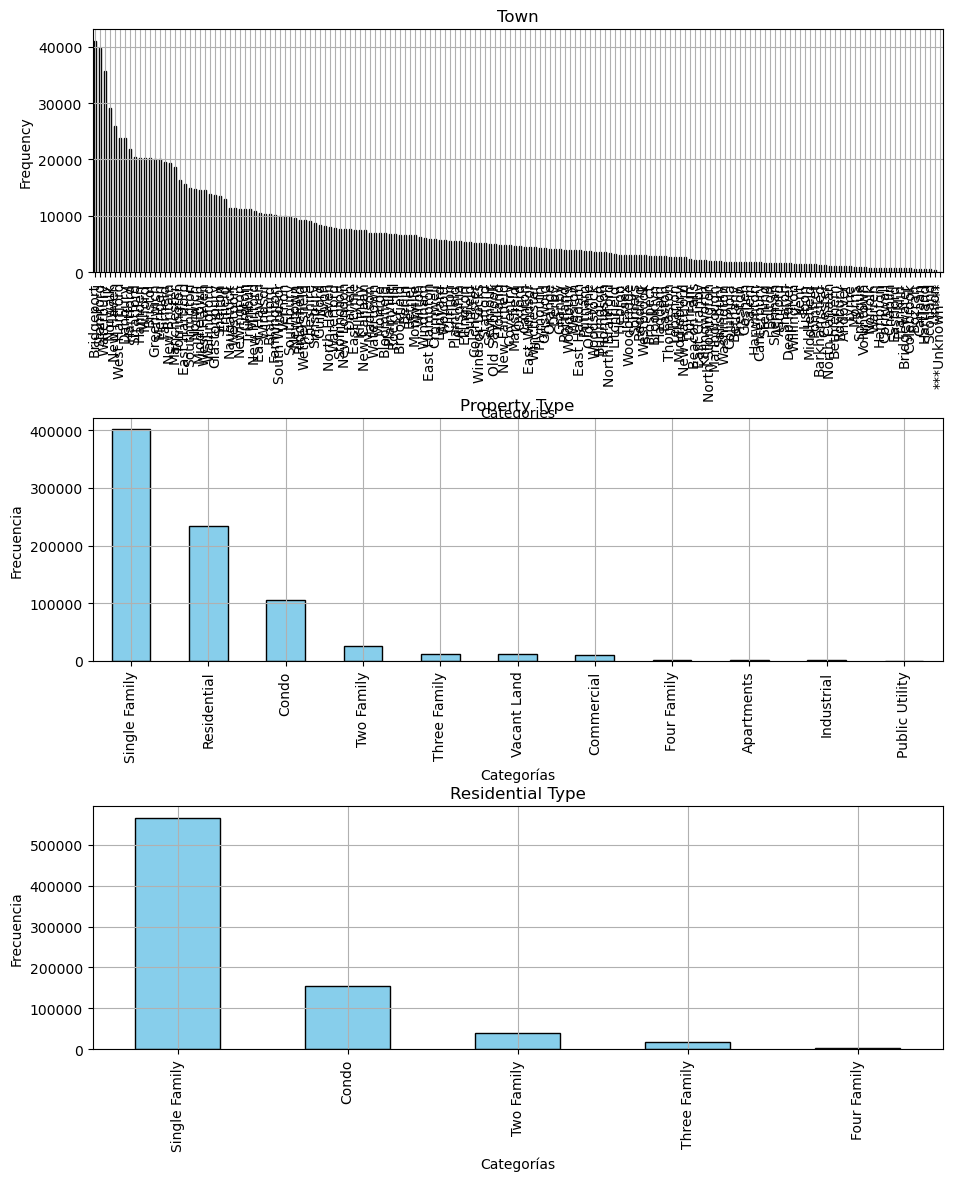

In [23]:
plt.figure(1, figsize=(10, 12))


plt.subplot(311)
X['Town'].value_counts().plot.bar(edgecolor='black', color='skyblue')
plt.title('Town')
plt.xlabel('Categories')
plt.ylabel('Frequency')
plt.grid(True)

plt.subplot(312) 
X['Property Type'].value_counts().plot.bar(edgecolor='black', color='skyblue')
plt.title('Property Type')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.grid(True)

plt.subplot(313)  
X['Residential Type'].value_counts().plot.bar(edgecolor='black', color='skyblue')
plt.title('Residential Type')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.grid(True)

plt.subplots_adjust(top=0.95, bottom=0.1, left=0.10, right=0.95, hspace=0.6, wspace=1)


plt.show()


Now we know have to apply binary encoding for feature 'Town', due to its high cardinality

## Measures of dispersion

In [24]:
X.head()

,Serial Number,List Year,Town,Assessed Value,Property Type,Residential Type,Year Recorded,Month Recorded,Day Recorded
0,24079,2024,Ashford,54460.0,Vacant Land,NaN,2025.0,9.0,26.0
1,240171,2024,Berlin,251400.0,Commercial,NaN,2025.0,6.0,6.0
2,24071,2024,Bethel,221480.0,Residential,Two Family,2024.0,12.0,31.0
3,24018,2024,Columbia,3640.0,Vacant Land,NaN,2024.0,12.0,18.0
4,240008,2024,Cromwell,96950.0,Residential,Condo,2024.0,10.0,11.0


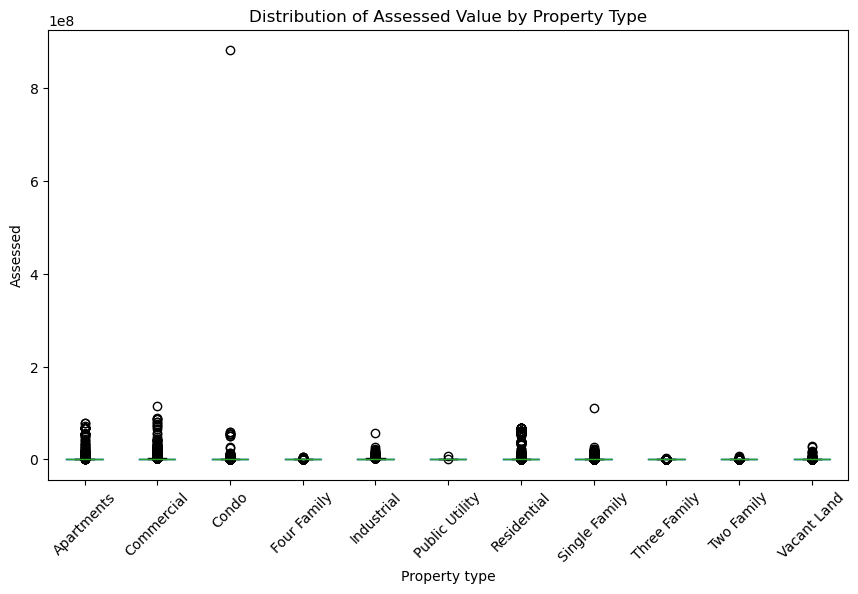

In [25]:
X.boxplot(column='Assessed Value', by='Property Type', figsize=(10, 6), grid=False)
plt.title('Distribution of Assessed Value by Property Type')
plt.suptitle('')
plt.xlabel('Property type')
plt.ylabel('Assessed')
plt.xticks(rotation=45) 
plt.show()

In [26]:
# Look for values above 80 million
outliers_extremos = X[X['Assessed Value'] > 800_000_000]
print(outliers_extremos[['Property Type', 'Assessed Value']])

X = X.drop(index=[375213])
y = y.drop(index=[375213])



       Property Type  Assessed Value
375213         Condo     881510000.0


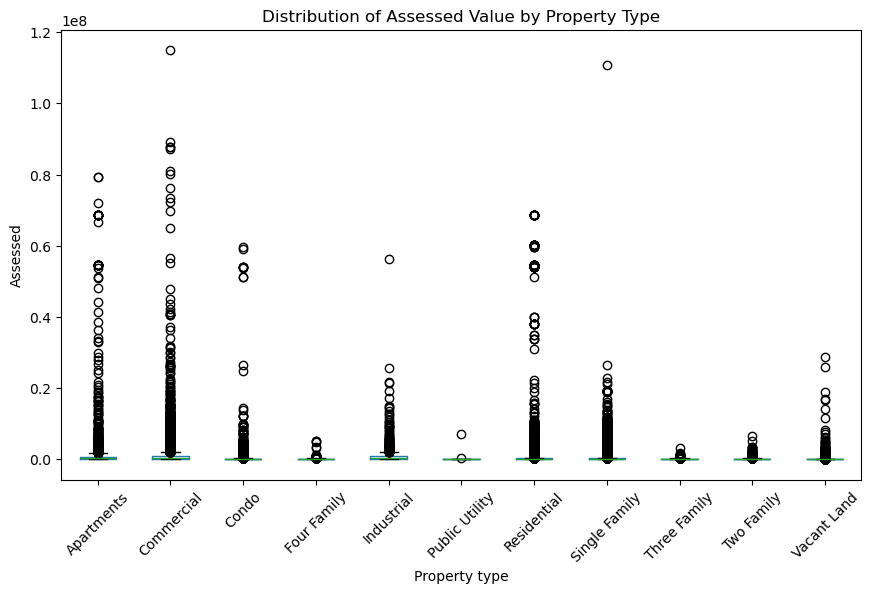

In [27]:
X.boxplot(column='Assessed Value', by='Property Type', figsize=(10, 6), grid=False)
plt.title('Distribution of Assessed Value by Property Type')
plt.suptitle('')
plt.xlabel('Property type')
plt.ylabel('Assessed')
plt.xticks(rotation=45) 
plt.show()

This is a clear symptom, our dataset has a right-skewed distribution then we would have to apply a logaritmic transformation so we compact the data 

In [28]:
X.head()

,Serial Number,List Year,Town,Assessed Value,Property Type,Residential Type,Year Recorded,Month Recorded,Day Recorded
0,24079,2024,Ashford,54460.0,Vacant Land,NaN,2025.0,9.0,26.0
1,240171,2024,Berlin,251400.0,Commercial,NaN,2025.0,6.0,6.0
2,24071,2024,Bethel,221480.0,Residential,Two Family,2024.0,12.0,31.0
3,24018,2024,Columbia,3640.0,Vacant Land,NaN,2024.0,12.0,18.0
4,240008,2024,Cromwell,96950.0,Residential,Condo,2024.0,10.0,11.0


## Boxplot for Residential Type

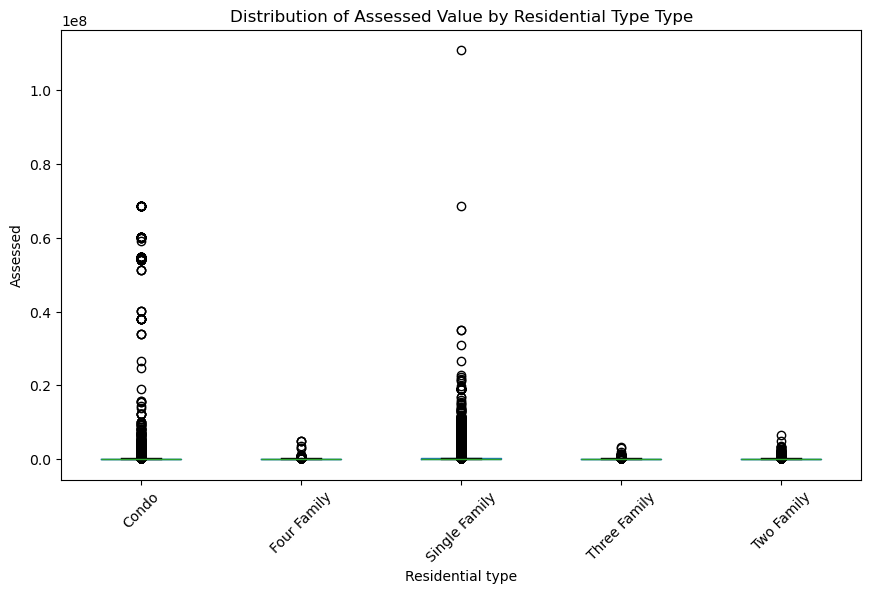

In [29]:
X.boxplot(column='Assessed Value', by='Residential Type', figsize=(10, 6), grid=False)
plt.title('Distribution of Assessed Value by Residential Type Type')
plt.suptitle('')
plt.xlabel('Residential type')
plt.ylabel('Assessed')
plt.xticks(rotation=45) 
plt.show()

Again the same pattern this combination has a right-skewed distribution, so we got to apply log transformation latter

In [30]:
X.head()

y.head()

0     95000.0
1    350000.0
2    480000.0
3     15000.0
4    179900.0
Name: Sale Amount, dtype: float64

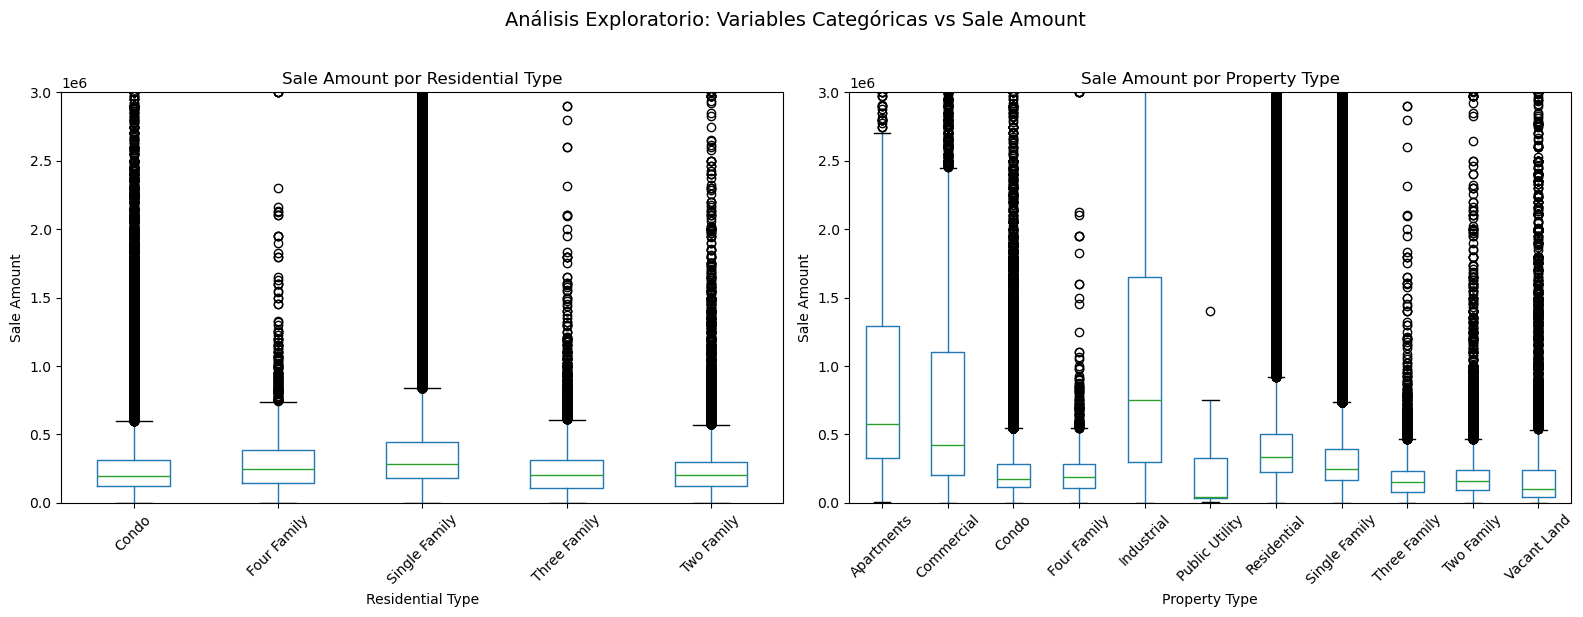

In [ ]:

df_temporal = X[['Residential Type', 'Property Type']].copy()
df_temporal['Sale Amount'] = y


fig, axes = plt.subplots(1, 2, figsize=(16, 6))


df_temporal.boxplot(column='Sale Amount', by='Residential Type', ax=axes[0], grid=False)
axes[0].set_title('Sale Amount por Residential Type')
axes[0].set_xlabel('Residential Type')
axes[0].set_ylabel('Sale Amount')
axes[0].tick_params(axis='x', rotation=45)


axes[0].set_ylim(0, 3_000_000) 


df_temporal.boxplot(column='Sale Amount', by='Property Type', ax=axes[1], grid=False)
axes[1].set_title('Sale Amount por Property Type')
axes[1].set_xlabel('Property Type')
axes[1].set_ylabel('Sale Amount')
axes[1].tick_params(axis='x', rotation=45)

axes[1].set_ylim(0, 3_000_000) 

plt.suptitle('Análisis Exploratorio: Variables Categóricas vs Sale Amount', fontsize=14, y=1.02)
plt.tight_layout()

plt.show()


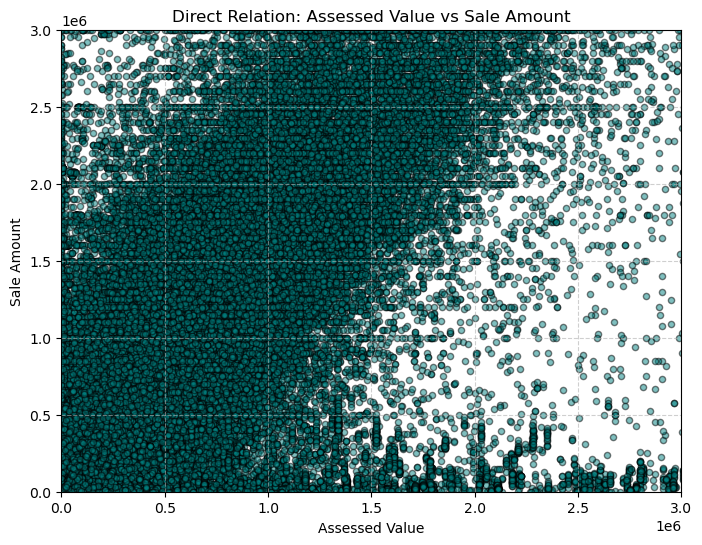

In [32]:


plt.figure(figsize=(8, 6))

# Graficamos las dos variables numéricas frente a frente
plt.scatter(X['Assessed Value'], y, alpha=0.5, color='teal', edgecolor='k', s=20)

plt.title('Direct Relation: Assessed Value vs Sale Amount')
plt.xlabel('Assessed Value')
plt.ylabel('Sale Amount')

# Use the same 3-million zoom so outliers do not flatten the diagonal
plt.xlim(0, 3_000_000)
plt.ylim(0, 3_000_000)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### Lets delete symbolic sales, it doesn't help much with our porpouse

Valid comercial registers: 1175714
Deleted noisy registers: 13282


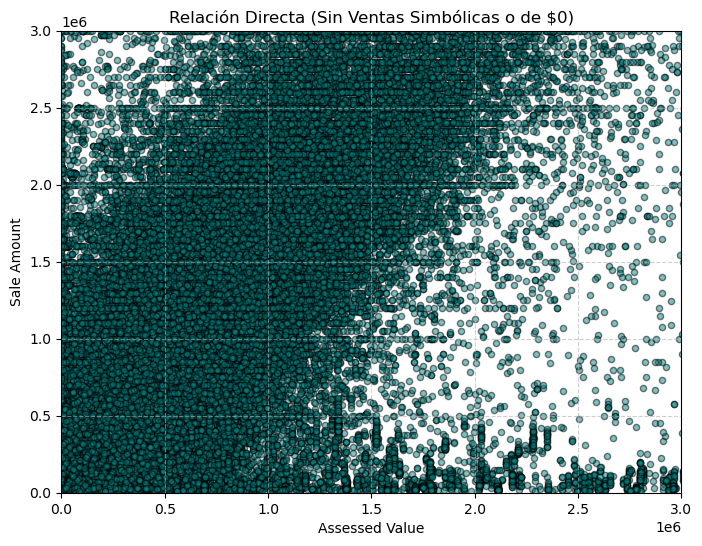

In [33]:

# 1. Definir un umbral de venta comercial mínimo (ej. $10,000)
umbral_minimo = 10000

# 2. Create a Boolean mask based on the target variable 'y'
mascara_comercial = y > umbral_minimo

# 3. Filtrar de forma sincronizada tanto X como y usando la máscara
X_filtrado = X[mascara_comercial].copy()
y_filtrado = y[mascara_comercial].copy()

# Show how many records were removed because they were symbolic values
registros_eliminados = len(y) - len(y_filtrado)
print(f"Valid comercial registers: {len(y_filtrado)}")
print(f"Deleted noisy registers: {registros_eliminados}")

# 4. Volver a graficar el Scatter Plot con los datos limpios
plt.figure(figsize=(8, 6))
plt.scatter(X_filtrado['Assessed Value'], y_filtrado, alpha=0.5, color='teal', edgecolor='k', s=20)

plt.title('Relación Directa (Sin Ventas Simbólicas o de $0)')
plt.xlabel('Assessed Value')
plt.ylabel('Sale Amount')

# Mantenemos el zoom visual de 3 millones para comparar la limpieza
plt.xlim(0, 3_000_000)
plt.ylim(0, 3_000_000)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


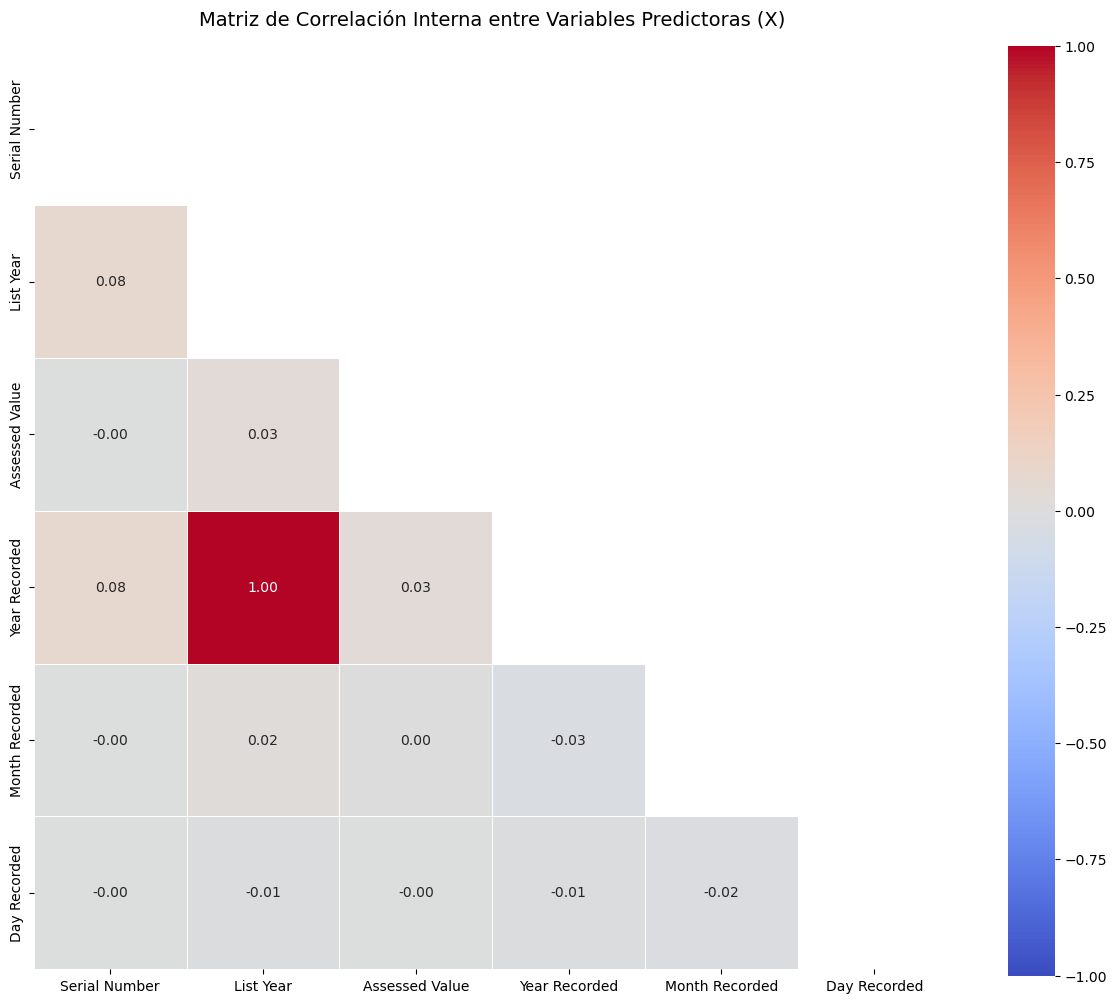

In [ ]:
import seaborn as sns


X_numericas = X.select_dtypes(include=[np.number])
matriz_corr_interna = X_numericas.corr()

plt.figure(figsize=(12, 10))
mascara = np.triu(np.ones_like(matriz_corr_interna, dtype=bool))


sns.heatmap(matriz_corr_interna, 
            mask=mascara,      
            annot=True,          
            fmt=".2f",           
            cmap="coolwarm",    
            vmin=-1, vmax=1,     
            linewidths=0.5,
            square=True)        

plt.title('Matriz de Correlación Interna entre Variables Predictoras (X)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


## Categorical variable distributions and relationship with price

This section analyzes the frequency of categories in `Residential Type` and `Property Type`. It also compares the distribution of `Sale Amount` across categories using boxplots.

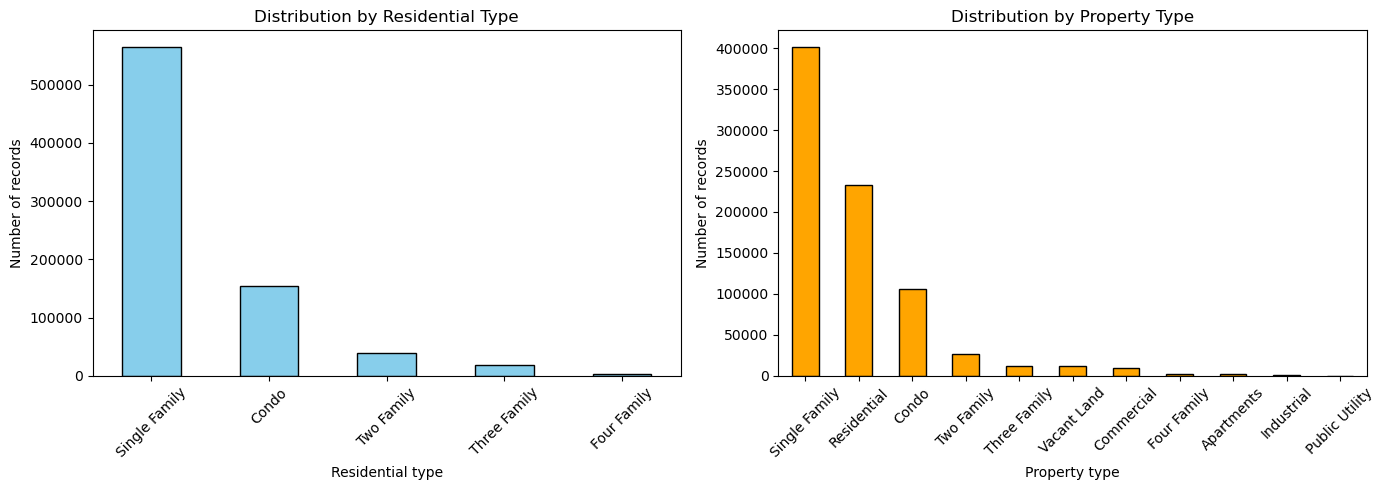

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Category counts, excluding missing values
residential_counts = data['Residential Type'].dropna().value_counts()
property_counts = data['Property Type'].dropna().value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residential_counts.plot(
    kind='bar', ax=axes[0], color='skyblue', edgecolor='black'
)
axes[0].set_title('Distribution by Residential Type')
axes[0].set_xlabel('Residential type')
axes[0].set_ylabel('Number of records')
axes[0].tick_params(axis='x', rotation=45)

property_counts.plot(
    kind='bar', ax=axes[1], color='orange', edgecolor='black'
)
axes[1].set_title('Distribution by Property Type')
axes[1].set_xlabel('Property type')
axes[1].set_ylabel('Number of records')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

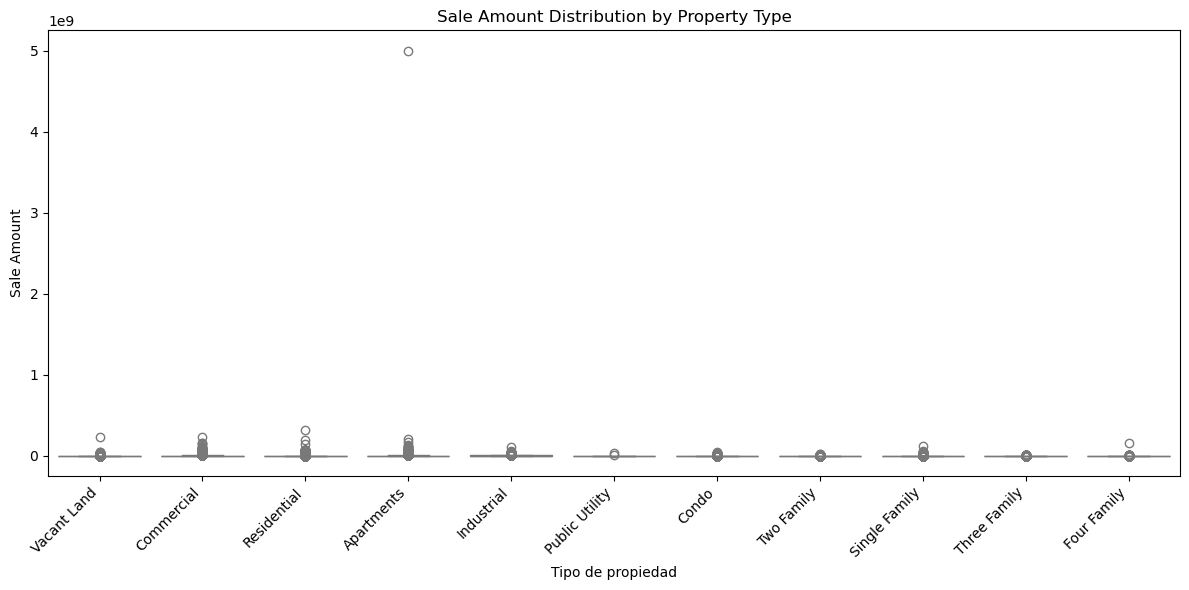

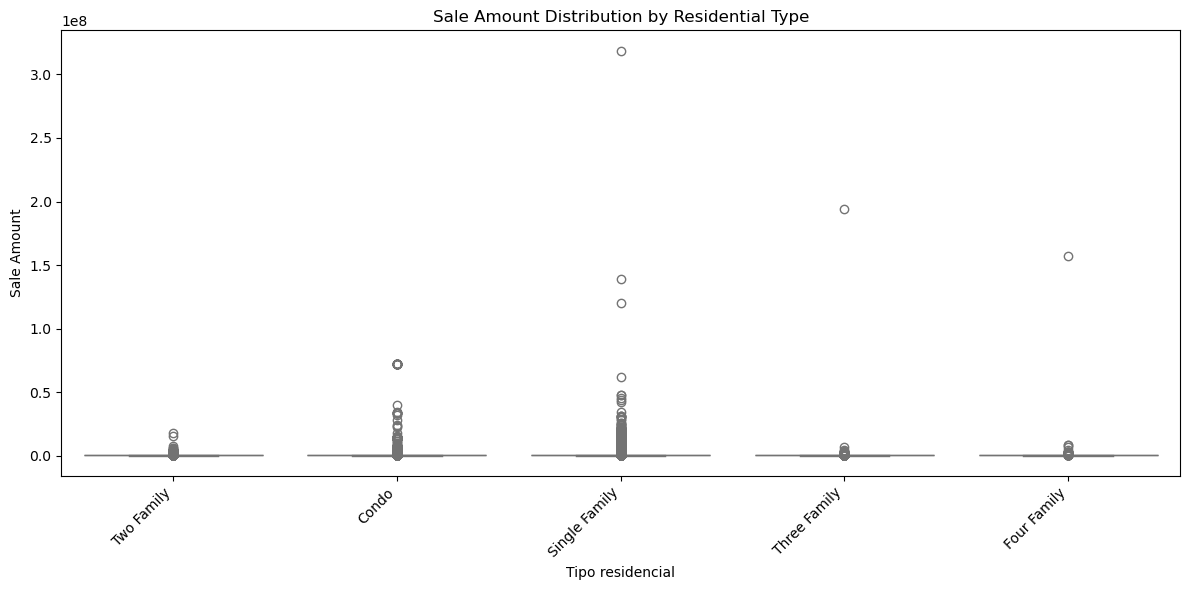

In [36]:
# Compare price distribution by property type
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x='Property Type', y='Sale Amount', color='lightblue')
plt.title('Sale Amount Distribution by Property Type')
plt.xlabel('Tipo de propiedad')
plt.ylabel('Sale Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Compare price distribution by residential type
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x='Residential Type', y='Sale Amount', color='lightgreen')
plt.title('Sale Amount Distribution by Residential Type')
plt.xlabel('Tipo residencial')
plt.ylabel('Sale Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Correlation with Sale Amount and multicollinearity

In [ ]:

numeric_data = data.select_dtypes(include=np.number).drop(columns=['Sales Ratio'], errors='ignore').copy()
correlation_with_target = numeric_data.corr(method='spearman')['Sale Amount'].drop('Sale Amount').sort_values(key=abs, ascending=False)
display(correlation_with_target.to_frame('Spearman with Sale Amount'))


def eta_squared(category, target):
    frame = pd.DataFrame({'category': category, 'target': target}).dropna()
    overall_mean = frame['target'].mean()
    grouped = frame.groupby('category', observed=True)['target']
    numerator = (grouped.size() * (grouped.mean() - overall_mean) ** 2).sum()
    denominator = ((frame['target'] - overall_mean) ** 2).sum()
    return numerator / denominator if denominator else 0

categorical_data = data.select_dtypes(include=['object', 'category', 'bool'])
eta_with_target = pd.Series({column: eta_squared(data[column], data['Sale Amount']) for column in categorical_data.columns}).sort_values(ascending=False)
display(eta_with_target.to_frame('Eta squared with Sale Amount'))

,Spearman with Sale Amount
Assessed Value,0.770252
Year Recorded,0.192067
List Year,0.190967
Serial Number,0.143583
Month Recorded,0.015472
Day Recorded,-0.012278


,Eta squared with Sale Amount
Sales Ratio,0.960569
Residential Type,0.005830
Town,0.005450
Property Type,0.002776


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X.select_dtypes(include=np.number).drop(columns=['Sale Amount'], errors='ignore').copy()
X_vif = X_vif.replace([np.inf, -np.inf], np.nan)
X_vif = X_vif.loc[:, X_vif.nunique(dropna=True) > 1]
X_vif = X_vif.fillna(X_vif.median())

vif_table = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)
display(vif_table)
print('VIF < 5: generally acceptable | 5-10: review | > 10: strong multicollinearity')

,Variable,VIF
1,List Year,3.303599e+07
3,Year Recorded,3.301406e+07
4,Month Recorded,9.974857e+00
5,Day Recorded,3.842371e+00
2,Assessed Value,1.039137e+00
0,Serial Number,1.005757e+00


VIF < 5: generally acceptable | 5-10: review | > 10: strong multicollinearity


## Visualization of correlations, associations, and VIF

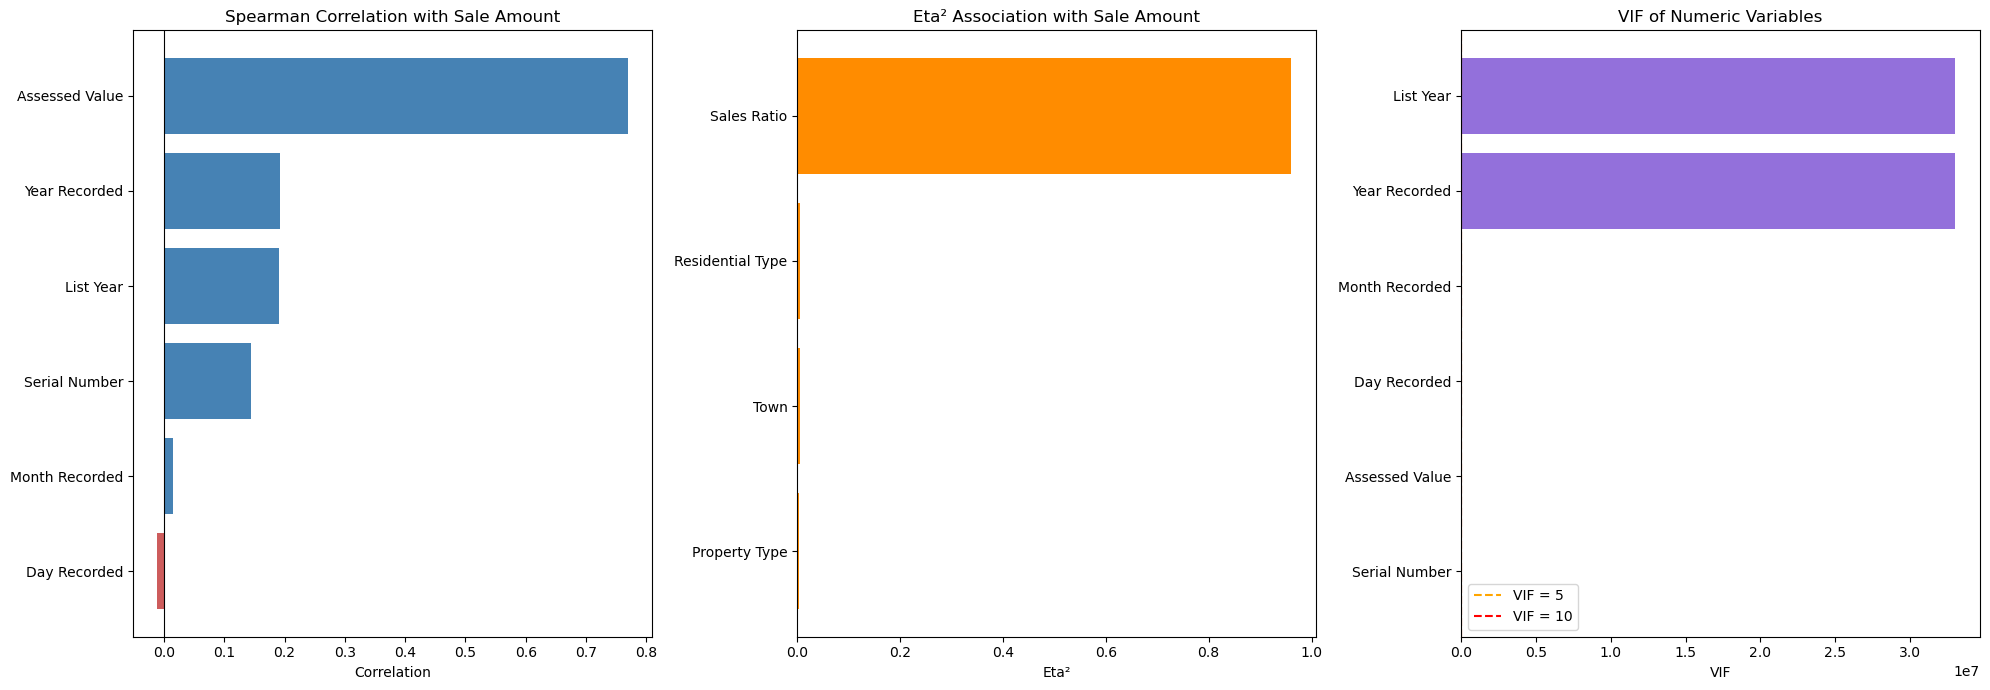

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

numeric_plot = correlation_with_target.sort_values()
axes[0].barh(numeric_plot.index, numeric_plot.values, color=np.where(numeric_plot.values >= 0, 'steelblue', 'indianred'))
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Spearman Correlation with Sale Amount')
axes[0].set_xlabel('Correlation')

eta_plot = eta_with_target.sort_values()
axes[1].barh(eta_plot.index, eta_plot.values, color='darkorange')
axes[1].set_title('Eta² Association with Sale Amount')
axes[1].set_xlabel('Eta²')

vif_plot = vif_table.sort_values('VIF')
axes[2].barh(vif_plot['Variable'], vif_plot['VIF'], color='mediumpurple')
axes[2].axvline(5, color='orange', linestyle='--', label='VIF = 5')
axes[2].axvline(10, color='red', linestyle='--', label='VIF = 10')
axes[2].set_title('VIF of Numeric Variables')
axes[2].set_xlabel('VIF')
axes[2].legend()

plt.tight_layout()
plt.show()

## Conclusions about EDA

* The dataset has a right-skewed distribution in features as 'Property Type' and 'Residential Type' so we need to apply logaritm transformation 
* Another fact is that it doesn't have a big correlation between variables (Bi-variate) neither a big multicollinearity measured by VIF, so this sound great by the side that each variable suppor information, but we will see the truth in the next conclusion 
* If we measure the correlation between target feature (Amount Sale) and each variable we find a strong relation between y and 'Assesed value', this suggest that the model will strongly biased by this unique variable and won't take into account the others
* The relation isn't linear, that why we got to use Pearson and thats the reason we lean strongly use a non-linear regressor model otherwise our predicted value would be incorrect as we saw before 
* We have a variable 'Town' that has multiple categories, thats why we got to use binary enconding to simplify the model while having the information. 


## Experimental Logarithmic Transformation

This experiment compares the original distributions of `Assessed Value` and `Sale Amount` with temporary `log1p` transformations. The original dataset and modeling variables remain unchanged.

In [ ]:
# Create temporary series so the original data remains unchanged
log_experiment_columns = ['Assessed Value', 'Sale Amount']
fig, axes = plt.subplots(len(log_experiment_columns), 2, figsize=(15, 10))

for row, column in enumerate(log_experiment_columns):
    original_values = pd.to_numeric(data[column], errors='coerce').dropna()
    original_values = original_values[original_values >= 0]
    transformed_values = np.log1p(original_values)

    sns.histplot(original_values, bins=60, ax=axes[row, 0], color='steelblue')
    axes[row, 0].set_title(f'Original Distribution: {column}')
    axes[row, 0].set_xlabel(column)
    axes[row, 0].set_ylabel('Frequency')

    sns.histplot(transformed_values, bins=60, ax=axes[row, 1], color='darkorange')
    axes[row, 1].set_title(f'Log1p Distribution: {column}')
    axes[row, 1].set_xlabel(f'log1p({column})')
    axes[row, 1].set_ylabel('Frequency')

plt.suptitle('Original vs. Logarithmically Transformed Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Hypothesis: List Year and Year Recorded May Be Redundant

The extremely high VIF values suggest that `List Year` and `Year Recorded` may explain almost the same temporal information. The following experiments test this hypothesis without modifying the original feature matrix.

In [42]:
# Compare both year variables using only rows where both values are available
year_comparison = X[['List Year', 'Year Recorded']].dropna().copy()
year_comparison['Year Difference'] = (
    year_comparison['List Year'] - year_comparison['Year Recorded']
)

pearson_years = year_comparison['List Year'].corr(
    year_comparison['Year Recorded'], method='pearson'
)
spearman_years = year_comparison['List Year'].corr(
    year_comparison['Year Recorded'], method='spearman'
)
same_year_percentage = (
    year_comparison['Year Difference'].eq(0).mean() * 100
)

year_summary = pd.DataFrame({
    'Metric': [
        'Pearson correlation',
        'Spearman correlation',
        'Rows with the same year (%)'
    ],
    'Value': [pearson_years, spearman_years, same_year_percentage]
})
display(year_summary)
display(
    year_comparison['Year Difference']
    .value_counts()
    .sort_index()
    .rename('Frequency')
    .to_frame()
)

,Metric,Value
0,Pearson correlation,0.998209
1,Spearman correlation,0.997752
2,Rows with the same year (%),25.212575


,Frequency
Year Difference,
-4.0,1
-3.0,3
-2.0,8
-1.0,888886
0.0,299687
1.0,15
2.0,15
3.0,6
4.0,3


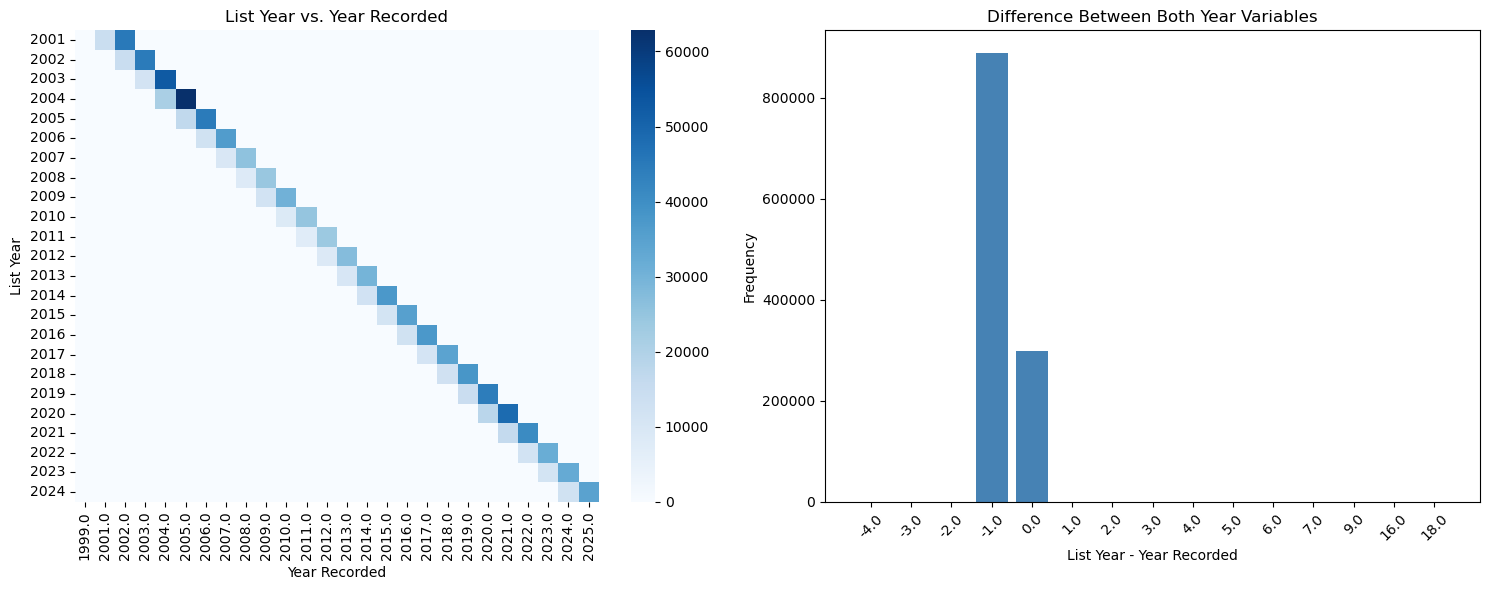

In [43]:
# Visualize whether both variables contain nearly identical year information
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

year_cross_table = pd.crosstab(
    year_comparison['List Year'],
    year_comparison['Year Recorded']
)
sns.heatmap(year_cross_table, cmap='Blues', ax=axes[0])
axes[0].set_title('List Year vs. Year Recorded')
axes[0].set_xlabel('Year Recorded')
axes[0].set_ylabel('List Year')

difference_counts = (
    year_comparison['Year Difference'].value_counts().sort_index()
)
axes[1].bar(
    difference_counts.index.astype(str),
    difference_counts.values,
    color='steelblue'
)
axes[1].set_title('Difference Between Both Year Variables')
axes[1].set_xlabel('List Year - Year Recorded')
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

It is common that the List Year and Recorded Year coincide in the same year, so this strengthens the previous hypothesis that both variables contribute the same information to the model

In [44]:
from statsmodels.tools.tools import add_constant

def calculate_vif_with_constant(features):
    numeric_features = features.select_dtypes(include=np.number).copy()
    numeric_features = numeric_features.replace([np.inf, -np.inf], np.nan)
    numeric_features = numeric_features.dropna(axis=1, how='all')
    numeric_features = numeric_features.loc[
        :, numeric_features.nunique(dropna=True) > 1
    ]
    numeric_features = numeric_features.fillna(numeric_features.median())
    numeric_features = add_constant(numeric_features, has_constant='add')

    result = pd.DataFrame({
        'Variable': numeric_features.columns,
        'VIF': [
            variance_inflation_factor(numeric_features.values, index)
            for index in range(numeric_features.shape[1])
        ]
    })
    return result[result['Variable'] != 'const'].sort_values(
        'VIF', ascending=False
    )

vif_both_years = calculate_vif_with_constant(X)
vif_without_list_year = calculate_vif_with_constant(
    X.drop(columns=['List Year'], errors='ignore')
)
vif_without_year_recorded = calculate_vif_with_constant(
    X.drop(columns=['Year Recorded'], errors='ignore')
)

vif_experiment = pd.concat([
    vif_both_years.assign(Scenario='Both year variables'),
    vif_without_list_year.assign(Scenario='Without List Year'),
    vif_without_year_recorded.assign(Scenario='Without Year Recorded')
])

display(
    vif_experiment.pivot(
        index='Variable', columns='Scenario', values='VIF'
    ).sort_index()
)

Scenario,Both year variables,Without List Year,Without Year Recorded
Variable,,,
Assessed Value,1.001079,1.001068,1.001055
Day Recorded,1.000844,1.000681,1.000697
List Year,433.339988,NaN,1.007331
Month Recorded,1.848348,1.001276,1.000747
Serial Number,1.005909,1.005882,1.005830
Year Recorded,433.583002,1.007896,NaN


### Conclusion about the presense of Year Recorded and List Recorded

As shown by the correlation and VIF analyses, Year Recorded and List Year provide almost the same temporal information. Therefore, we decided to remove List Year and retain Year Recorded, since it is part of the complete recorded date together with Month Recorded and Day Recorded.